# Quality Analysis: Resolved vs Unresolved Trajectories

Comparing OpenHands rollout trajectories on **SWE-Gym (train)** that pass vs. fail tests, along the following axes:

1. Interaction length (#agent steps, total history events, tokens)
2. Tool misuse (error observations / failed tool calls)
3. Stuck-in-loop (repeated identical actions)
4. Redundant exploration (re-reading files / re-running same exploration commands)

In [1]:
import json, os, re, gzip
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_DIR = (
    "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/"
    "SWE-Gym__SWE-Gym-train/CodeActAgent/"
    "Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/"
    "Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_1"
)

# RUN_DIR = ("/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-no-hint-train-glm5_fp8_t05-run_1")
OUTPUT_FILE = os.path.join(RUN_DIR, "output.jsonl")  # has both `history` and `report`
print("Run dir:", RUN_DIR)
print("Output file exists:", os.path.exists(OUTPUT_FILE))

Run dir: /home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_1
Output file exists: True


## 1. Load trajectories & resolution status

In [2]:
def load_entries(path):
    entries = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                entries.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return entries

entries = load_entries(OUTPUT_FILE)
print(f"Total entries: {len(entries)}")

def is_resolved(e):
    rep = e.get("report")
    if isinstance(rep, dict) and rep.get("resolved"):
        return True
    tr = e.get("test_result") or {}
    if isinstance(tr, dict):
        rep2 = tr.get("report")
        if isinstance(rep2, dict) and rep2.get("resolved"):
            return True
    return False

for e in entries:
    e["_resolved"] = is_resolved(e)

n_res = sum(1 for e in entries if e["_resolved"])
n_unr = len(entries) - n_res
print(f"Resolved:   {n_res}")
print(f"Unresolved: {n_unr}")
print(f"Resolve rate: {100*n_res/len(entries):.1f}%")

Total entries: 2119
Resolved:   634
Unresolved: 1485
Resolve rate: 29.9%


## 2. Trajectory analysis helpers

* **Interaction length**: number of agent actions, total history events, accumulated tokens.
* **Tool misuse**: observations whose `observation == 'error'` or `success == False`, or run-command observations whose exit code is non-zero (excluding test runs which legitimately fail).
* **Stuck-in-loop**: (a) the engine's own `StuckInLoop` error string, OR (b) `min_repeat` consecutive identical action fingerprints.
* **Redundant exploration**: read/exploration actions whose target was already inspected earlier in the trajectory.

In [3]:
def normalize_command(cmd):
    if not cmd:
        return ""
    return re.sub(r"\s+", " ", cmd).strip()

def make_fingerprint(action, args):
    if action == "run":
        return f"run:{normalize_command(args.get('command', ''))[:200]}"
    if action == "edit":
        sub = (args.get("command", "") or "").strip()
        path = (args.get("path", "") or "").strip()
        return f"edit:{sub}:{path}"
    if action == "read":
        path = (args.get("path", "") or "").strip()
        vr = args.get("view_range")
        s = args.get("start"); e = args.get("end")
        rng = tuple(vr) if isinstance(vr, list) else (s, e)
        return f"read:{path}:{rng}"
    if action == "think":
        return f"think:{(args.get('thought','') or '')[:120]}"
    return f"{action}"

# Exact OpenHands edit sub-commands observed in this dataset:
#   str_replace, create  (both MUTATE the file)
# `read` is the only read-only file-view action; bash explorations
# (cat/grep/...) are intentionally excluded from "redundant exploration"
# because they don't share the same path+line-range semantics.
EDIT_VIEW_SUBCOMMANDS = {"view", "open"}  # not actually used in this run, kept for safety

def _read_target(action, args):
    """If this action views a file with a (path, line_range), return (path, (start,end)).
    Otherwise return None."""
    if action == "read":
        path = (args.get("path", "") or "").strip()
        if not path:
            return None
        vr = args.get("view_range")
        s = args.get("start"); e = args.get("end")
        if isinstance(vr, list) and len(vr) == 2:
            rng = (vr[0], vr[1])
        elif s is not None or e is not None:
            rng = (s, e)
        else:
            rng = (None, None)
        return (path, rng)
    if action == "edit":
        sub = (args.get("command", "") or "").strip().lower()
        if sub in EDIT_VIEW_SUBCOMMANDS:
            path = (args.get("path", "") or "").strip()
            if not path:
                return None
            vr = args.get("view_range")
            rng = tuple(vr) if isinstance(vr, list) and len(vr) == 2 else (None, None)
            return (path, rng)
    return None

def _is_mutating_edit(action, args):
    """Edits that change file contents (so previous reads of that path become stale)."""
    if action != "edit":
        return False
    sub = (args.get("command", "") or "").strip().lower()
    return sub not in EDIT_VIEW_SUBCOMMANDS  # everything except view/open mutates

def ranges_overlap(a, b):
    s1, e1 = a; s2, e2 = b
    if s1 in (None, -1) and e1 in (None, -1):
        return True
    if s2 in (None, -1) and e2 in (None, -1):
        return True
    s1 = 0      if s1 in (None, -1) else s1
    e1 = 10**9  if e1 in (None, -1) else e1
    s2 = 0      if s2 in (None, -1) else s2
    e2 = 10**9  if e2 in (None, -1) else e2
    return not (e1 < s2 or e2 < s1)

def count_redundant_exploration(agent_actions):
    """Redundant exploration = a `read`/edit-view action whose (path, line range)
    has been viewed earlier in the same trajectory.

    Important refinements vs. a naive implementation:
      * Only `read` and explicit `edit view/open` count as exploration. Bash
        commands (cat/grep/find/...) are NOT counted because they don't expose
        a comparable (path, line_range) target and they pollute counts.
      * When the agent MUTATES a file (any edit sub-command other than view),
        the seen-range cache for that path is cleared -- re-reading a file you
        just changed is a legitimate verification, not redundancy.
    """
    seen_ranges = defaultdict(list)  # path -> [ (start,end), ... ]  reset on edit
    explore_steps = 0
    redundant_steps = 0
    redundant_exact = 0
    redundant_overlap = 0
    paths_revisited = set()

    for a in agent_actions:
        action = a.get("action", "")
        args   = a.get("args", {}) or {}

        # Mutation invalidates previous reads of the file
        if _is_mutating_edit(action, args):
            path = (args.get("path", "") or "").strip()
            if path:
                seen_ranges.pop(path, None)
            continue

        target = _read_target(action, args)
        if target is None:
            continue
        path, rng = target
        explore_steps += 1
        prev = seen_ranges.get(path, [])
        if prev:
            if rng in prev:
                redundant_exact += 1
                redundant_steps += 1
                paths_revisited.add(path)
            elif any(ranges_overlap(rng, p) for p in prev):
                redundant_overlap += 1
                redundant_steps += 1
                paths_revisited.add(path)
        seen_ranges[path].append(rng)

    total_actions = max(len(agent_actions), 1)
    return {
        "explore_steps": explore_steps,
        "redundant_explore_steps": redundant_steps,
        "redundant_exact": redundant_exact,
        "redundant_overlap": redundant_overlap,
        "redundant_explore_rate": redundant_steps / total_actions,
        "unique_paths_revisited": len(paths_revisited),
    }

def detect_stuck_in_loop(agent_actions, error_str, min_repeat=5):
    if error_str and ("StuckInLoop" in error_str or "stuck in a loop" in error_str.lower()):
        return True
    fps = [make_fingerprint(a.get("action",""), a.get("args", {}) or {}) for a in agent_actions]
    for i in range(len(fps) - min_repeat + 1):
        window = fps[i:i+min_repeat]
        if all(w == window[0] for w in window):
            return True
    return False

def is_test_command(cmd):
    if not cmd:
        return False
    return bool(re.search(r"\b(pytest|tox|unittest|nose2|py\.test|npm test|jest|go test|cargo test)\b", cmd))

def analyze_trajectory(entry):
    history = entry.get("history") or []
    agent_actions = [e for e in history if e.get("source") == "agent" and "action" in e]
    observations = [e for e in history if "observation" in e]

    action_types = Counter(a.get("action", "unknown") for a in agent_actions)

    misuse = 0
    for o in observations:
        obs_t = o.get("observation")
        if obs_t == "error":
            misuse += 1; continue
        if o.get("success") is False:
            misuse += 1; continue
        if obs_t == "run":
            ext = o.get("extras") or {}
            ec = ext.get("exit_code", o.get("exit_code"))
            cmd = (o.get("args") or {}).get("command") or ext.get("command") or ""
            if isinstance(ec, int) and ec != 0 and not is_test_command(cmd):
                misuse += 1

    redund = count_redundant_exploration(agent_actions)
    error_str = entry.get("error") or ""
    stuck = detect_stuck_in_loop(agent_actions, error_str)

    metrics = entry.get("metrics") or {}
    tu = metrics.get("accumulated_token_usage") or {}

    return {
        "instance_id": entry.get("instance_id"),
        "resolved": entry["_resolved"],
        "history_len": len(history),
        "step_count": len(agent_actions),
        "observation_count": len(observations),
        "tool_misuse_count": misuse,
        "tool_misuse_rate": misuse / max(len(observations), 1),
        "stuck_in_loop": stuck,
        "prompt_tokens": tu.get("prompt_tokens", 0),
        "completion_tokens": tu.get("completion_tokens", 0),
        "cost": metrics.get("accumulated_cost", 0),
        "action_types": dict(action_types),
        **redund,
        "error": error_str[:200],
    }

stats = [analyze_trajectory(e) for e in entries]
df = pd.DataFrame(stats)
print(df.shape)
df.head()


(2119, 19)


,instance_id,resolved,history_len,step_count,observation_count,tool_misuse_count,tool_misuse_rate,stuck_in_loop,prompt_tokens,completion_tokens,cost,action_types,explore_steps,redundant_explore_steps,redundant_exact,redundant_overlap,redundant_explore_rate,unique_paths_revisited,error
0,getmoto__moto-4950,True,95,47,46,3,0.065217,False,1047366,10483,0.0,"{'system': 1, 'think': 2, 'read': 12, 'run': 2...",12,1,0,1,0.021277,1,
1,getmoto__moto-5876,False,111,55,54,4,0.074074,False,1086869,11339,0.0,"{'system': 1, 'think': 2, 'read': 13, 'run': 3...",13,2,0,2,0.036364,2,
2,getmoto__moto-5212,False,133,66,65,3,0.046154,False,2471896,13644,0.0,"{'system': 1, 'think': 2, 'read': 18, 'run': 3...",18,4,0,4,0.060606,3,
3,getmoto__moto-5386,True,145,72,71,3,0.042254,False,2431887,13393,0.0,"{'system': 1, 'think': 3, 'read': 20, 'run': 3...",20,7,0,7,0.097222,2,
4,getmoto__moto-6920,True,133,66,65,3,0.046154,False,1608370,14109,0.0,"{'system': 1, 'think': 2, 'read': 23, 'run': 3...",23,10,0,10,0.151515,2,


## 3. Aggregate comparison: resolved vs unresolved

In [4]:
metric_cols = [
    "step_count", "history_len", "observation_count",
    "tool_misuse_count", "tool_misuse_rate",
    "explore_steps", "redundant_explore_steps", "redundant_explore_rate",
    "redundant_exact", "redundant_overlap", "unique_paths_revisited",
    "prompt_tokens", "completion_tokens", "cost",
]

summary = df.groupby("resolved")[metric_cols].agg(["mean", "median", "std"]).T
summary.columns = ["unresolved" if not c else "resolved" for c in summary.columns]
summary

unresolved      resolved
step_count              mean    7.522694e+01  6.566246e+01
                        median  7.500000e+01  6.200000e+01
                        std     2.170872e+01  1.782581e+01
history_len             mean    1.511556e+02  1.319795e+02
                        median  1.510000e+02  1.250000e+02
                        std     4.330441e+01  3.518825e+01
observation_count       mean    7.395690e+01  6.431073e+01
                        median  7.400000e+01  6.000000e+01
                        std     2.164226e+01  1.759631e+01
tool_misuse_count       mean    6.538047e+00  5.452681e+00
                        median  6.000000e+00  5.000000e+00
                        std     4.576918e+00  4.127716e+00
tool_misuse_rate        mean    8.470893e-02  8.114131e-02
                        median  7.692308e-02  7.407407e-02
                        std     5.252754e-02  5.015237e-02
explore_steps           mean    1.936768e+01  1.630915e+01
                        median  1.800000e+01  1.500000e+01
                        std     8.153235e+00  6.211568e+00
redundant_explore_steps mean    5.694949e+00  4.465300e+00
                        median  5.000000e+00  4.000000e+00
                        std     3.887988e+00  3.067368e+00
redundant_explore_rate  mean    7.179061e-02  6.554715e-02
                        median  6.930693e-02  6.153846e-02
                        std     4.160634e-02  3.747654e-02
redundant_exact         mean    2.276094e-01  2.634069e-01
                        median  0.000000e+00  0.000000e+00
                        std     5.669871e-01  6.964263e-01
redundant_overlap       mean    5.467340e+00  4.201893e+00
                        median  5.000000e+00  4.000000e+00
                        std     3.789052e+00  2.936978e+00
unique_paths_revisited  mean    2.247811e+00  1.872240e+00
                        median  2.000000e+00  2.000000e+00
                        std     1.300737e+00  1.074368e+00
prompt_tokens           mean    2.781165e+06  2.190166e+06
                        median  2.623520e+06  1.929764e+06
                        std     1.314306e+06  1.063025e+06
completion_tokens       mean    1.605947e+04  1.339469e+04
                        median  1.519000e+04  1.250800e+04
                        std     5.922689e+03  4.141022e+03
cost                    mean    0.000000e+00  0.000000e+00
                        median  0.000000e+00  0.000000e+00
                        std     0.000000e+00  0.000000e+00

In [5]:
# Stuck in loop
stuck_tbl = df.groupby("resolved")["stuck_in_loop"].agg(["sum", "count"])
stuck_tbl["rate_%"] = 100 * stuck_tbl["sum"] / stuck_tbl["count"]
stuck_tbl.index = ["unresolved" if not r else "resolved" for r in stuck_tbl.index]
print("Stuck in loop:")
print(stuck_tbl)

# Any tool misuse / any redundant exploration
for col in ["tool_misuse_count", "redundant_explore_steps"]:
    has = df[col] > 0
    t = df.assign(_h=has).groupby("resolved")["_h"].agg(["sum", "count"])
    t["rate_%"] = 100 * t["sum"] / t["count"]
    t.index = ["unresolved" if not r else "resolved" for r in t.index]
    print(f"\nInstances with {col} > 0:")
    print(t)

Stuck in loop:
            sum  count    rate_%
unresolved  106   1485  7.138047
resolved     27    634  4.258675

Instances with tool_misuse_count > 0:
             sum  count     rate_%
unresolved  1422   1485  95.757576
resolved     608    634  95.899054

Instances with redundant_explore_steps > 0:
             sum  count     rate_%
unresolved  1418   1485  95.488215
resolved     600    634  94.637224


## 4. Visualizations

/tmp/ipykernel_2834661/969645650.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([res, unr], labels=[f"Resolved\n(n={len(res)})", f"Unresolved\n(n={len(unr)})"],
/tmp/ipykernel_2834661/969645650.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([res, unr], labels=[f"Resolved\n(n={len(res)})", f"Unresolved\n(n={len(unr)})"],
/tmp/ipykernel_2834661/969645650.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([res, unr], labels=[f"Resolved\n(n={len(res)})", f"Unresolved\n(n={len(unr)})"],
/tmp/ipykernel_2834661/969645650.py:9: MatplotlibDeprecationWarning: The 'label

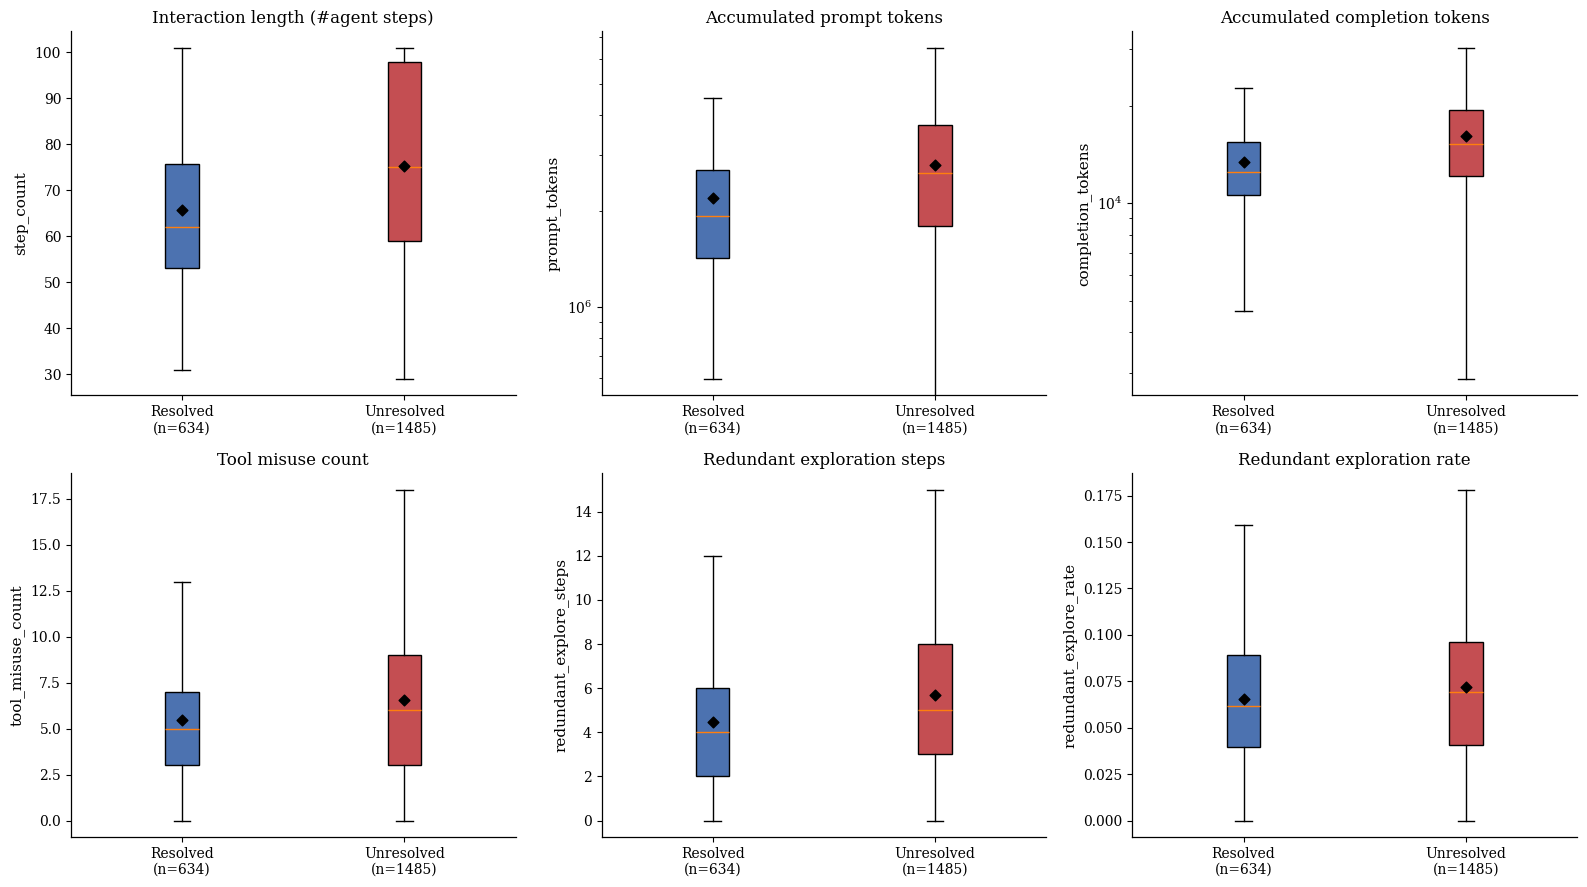

In [8]:
RES_COLOR = "#4C72B0"
UNR_COLOR = "#C44E52"

def split_resolved(col):
    return df.loc[df.resolved, col].values, df.loc[~df.resolved, col].values

def boxplot_compare(ax, col, title=None, log=False):
    res, unr = split_resolved(col)
    bp = ax.boxplot([res, unr], labels=[f"Resolved\n(n={len(res)})", f"Unresolved\n(n={len(unr)})"],
                    patch_artist=True, showfliers=False)
    bp["boxes"][0].set_facecolor(RES_COLOR)
    bp["boxes"][1].set_facecolor(UNR_COLOR)
    ax.set_title(title or col)
    ax.set_ylabel(col)
    if log:
        ax.set_yscale("log")
    # mean markers
    ax.scatter([1, 2], [np.mean(res) if len(res) else 0, np.mean(unr) if len(unr) else 0],
               marker="D", color="black", zorder=5, s=30, label="mean")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
boxplot_compare(axes[0,0], "step_count", "Interaction length (#agent steps)")
boxplot_compare(axes[0,1], "prompt_tokens", "Accumulated prompt tokens", log=True)
boxplot_compare(axes[0,2], "completion_tokens", "Accumulated completion tokens", log=True)
boxplot_compare(axes[1,0], "tool_misuse_count", "Tool misuse count")
boxplot_compare(axes[1,1], "redundant_explore_steps", "Redundant exploration steps")
boxplot_compare(axes[1,2], "redundant_explore_rate", "Redundant exploration rate")
plt.tight_layout()
plt.show()

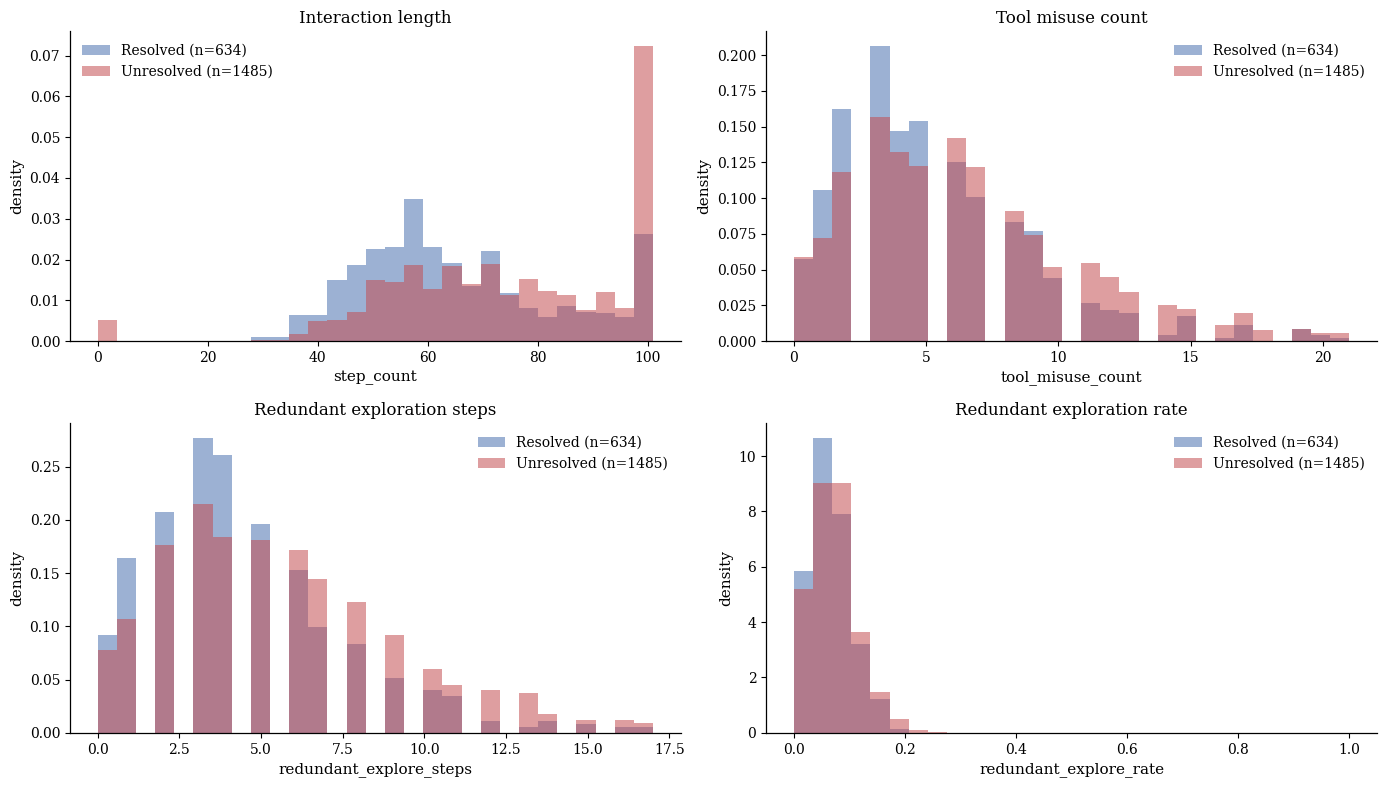

In [9]:
# Histograms (overlaid)
def hist_compare(ax, col, bins=30, title=None, clip_pct=99):
    res, unr = split_resolved(col)
    all_vals = np.concatenate([res, unr])
    if len(all_vals) == 0:
        return
    hi = np.percentile(all_vals, clip_pct)
    lo = float(all_vals.min())
    bin_edges = np.linspace(lo, max(hi, lo + 1), bins)
    ax.hist(res, bins=bin_edges, alpha=0.55, color=RES_COLOR, label=f"Resolved (n={len(res)})", density=True)
    ax.hist(unr, bins=bin_edges, alpha=0.55, color=UNR_COLOR, label=f"Unresolved (n={len(unr)})", density=True)
    ax.set_title(title or col)
    ax.set_xlabel(col); ax.set_ylabel("density"); ax.legend()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
hist_compare(axes[0,0], "step_count", title="Interaction length")
hist_compare(axes[0,1], "tool_misuse_count", title="Tool misuse count")
hist_compare(axes[1,0], "redundant_explore_steps", title="Redundant exploration steps")
hist_compare(axes[1,1], "redundant_explore_rate", title="Redundant exploration rate")
plt.tight_layout()
plt.show()

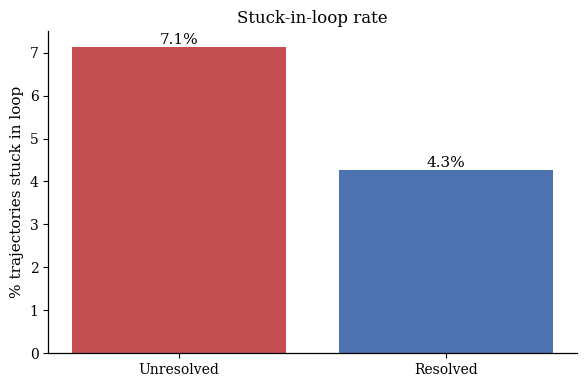

In [10]:
# Stuck-in-loop bar chart
fig, ax = plt.subplots(figsize=(6, 4))
rates = df.groupby("resolved")["stuck_in_loop"].mean() * 100
labels = ["Unresolved" if not r else "Resolved" for r in rates.index]
colors = [UNR_COLOR if not r else RES_COLOR for r in rates.index]
bars = ax.bar(labels, rates.values, color=colors)
ax.set_ylabel("% trajectories stuck in loop")
ax.set_title("Stuck-in-loop rate")
ax.bar_label(bars, fmt="%.1f%%")
plt.tight_layout()
plt.show()

### Publication-quality summary figure
A single, paper-ready figure summarizing the three behavioural axes (interaction length, tool misuse, redundant exploration) for **resolved vs. unresolved** trajectories.

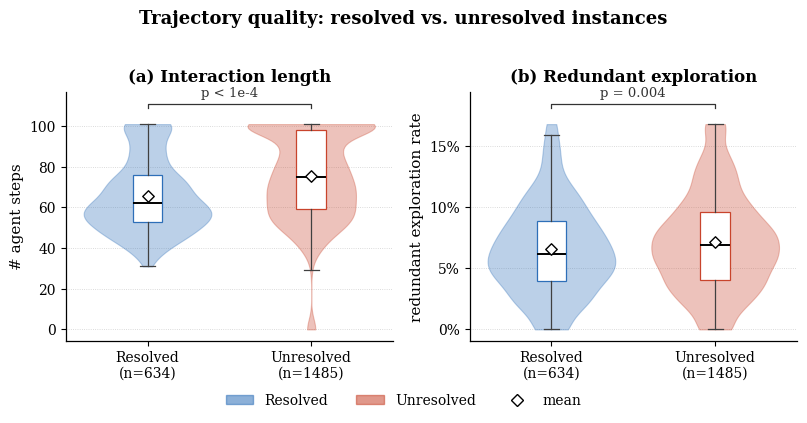

Mann-Whitney p-values:
  step_count                    p < 1e-4
  redundant_explore_rate        p = 0.004
Saved -> quality_summary.pdf / quality_summary.png


In [11]:
# ----- NeurIPS-style summary figure: Resolved vs Unresolved -----
# Two panels:  (a) interaction length    (b) redundant exploration
# Each panel shows a violin + slim box overlay, sample size, mean diamond, and
# a Mann-Whitney p-value annotation for at-a-glance significance.

import matplotlib as mpl
from scipy.stats import mannwhitneyu

mpl.rcParams.update({
    "font.family":      "DejaVu Serif",
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "axes.linewidth":    0.9,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   10,
    "legend.frameon":    False,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
    "savefig.bbox":      "tight",
    "savefig.dpi":       300,
})

C_RES = "#2E6FB8"   # resolved (blue)
C_UNR = "#C8442C"   # unresolved (red)

def _fmt_p(p):
    if not np.isfinite(p):
        return "n/a"
    if p < 1e-4:  return "p < 1e-4"
    if p < 1e-3:  return f"p = {p:.1e}"
    return f"p = {p:.3f}"

def _violin_box(ax, res, unr, ylabel, title, log=False, clip_pct=98):
    data = [np.asarray(res, dtype=float), np.asarray(unr, dtype=float)]
    positions = [1, 2]
    colors    = [C_RES, C_UNR]

    all_vals = np.concatenate(data) if len(data[0]) + len(data[1]) else np.array([0.0])
    cap = np.percentile(all_vals, clip_pct)
    plot_data = [np.clip(d, None, cap) if len(d) else d for d in data]

    parts = ax.violinplot(plot_data, positions=positions, widths=0.78,
                          showmeans=False, showmedians=False, showextrema=False)
    for body, c in zip(parts["bodies"], colors):
        body.set_facecolor(c); body.set_edgecolor(c)
        body.set_alpha(0.32);  body.set_linewidth(0.8)

    bp = ax.boxplot(plot_data, positions=positions, widths=0.18,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color="black", linewidth=1.4),
                    whiskerprops=dict(color="0.25", linewidth=0.9),
                    capprops=dict(color="0.25", linewidth=0.9),
                    boxprops=dict(linewidth=0.9))
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor("white"); patch.set_edgecolor(c)

    means = [d.mean() if len(d) else 0 for d in data]
    means_plot = [min(m, cap) for m in means]
    ax.scatter(positions, means_plot, marker="D", s=34,
               facecolor="white", edgecolor="black", linewidth=1.0,
               zorder=5, label="mean")

    try:
        _, p = mannwhitneyu(data[0], data[1], alternative="two-sided")
    except ValueError:
        p = float("nan")

    ymax = max((d.max() if len(d) else 0) for d in plot_data)
    ymin = min((d.min() if len(d) else 0) for d in plot_data)
    span = (ymax - ymin) if ymax > ymin else max(ymax, 1.0)
    bar_y = ymax + 0.08 * span
    ax.plot([1, 1, 2, 2], [bar_y, bar_y + 0.02*span, bar_y + 0.02*span, bar_y],
            color="0.2", linewidth=0.9)
    ax.text(1.5, bar_y + 0.04*span, _fmt_p(p),
            ha="center", va="bottom", fontsize=9.5, color="0.2")

    ax.set_xticks(positions)
    ax.set_xticklabels([f"Resolved\n(n={len(data[0])})",
                        f"Unresolved\n(n={len(data[1])})"])
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=8, fontweight="bold")
    if log:
        ax.set_yscale("log")
    ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)
    return p

panels = [
    ("step_count",              "# agent steps",                "(a) Interaction length"),
    ("redundant_explore_rate",  "redundant exploration rate",   "(b) Redundant exploration"),
]

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))
p_values = {}
for ax, (col, ylabel, title) in zip(axes, panels):
    res, unr = split_resolved(col)
    p_values[col] = _violin_box(ax, res, unr, ylabel, title)

for ax, (col, _, _) in zip(axes, panels):
    if col.endswith("_rate"):
        ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1.0, decimals=0))

legend_handles = [
    mpl.patches.Patch(facecolor=C_RES, edgecolor=C_RES, alpha=0.55, label="Resolved"),
    mpl.patches.Patch(facecolor=C_UNR, edgecolor=C_UNR, alpha=0.55, label="Unresolved"),
    mpl.lines.Line2D([0], [0], marker="D", linestyle="",
                     markerfacecolor="white", markeredgecolor="black", label="mean"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.06))

fig.suptitle("Trajectory quality: resolved vs. unresolved instances",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()

out_dir = "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_analysis/quality_analysis"
fig.savefig(os.path.join(out_dir, "quality_summary.pdf"))
fig.savefig(os.path.join(out_dir, "quality_summary.png"))
plt.show()

print("Mann-Whitney p-values:")
for k, v in p_values.items():
    print(f"  {k:<28s}  {_fmt_p(v)}")
print("Saved -> quality_summary.pdf / quality_summary.png")


### Effect of curation: before vs. after
Same two-panel figure, but contrasting **rollout trajectories (before curation)** with the **curated trajectories (after curation)**. The "before" distribution mirrors the resolved rollouts above; the "after" distribution is *simulated* with a small downward shift to illustrate the expected effect — shorter interactions and a ~3 pp drop in redundant exploration.


Interaction length:    before mean=65.7  after mean=58.9
Redundant exploration: before mean=6.55%  after mean=5.28%


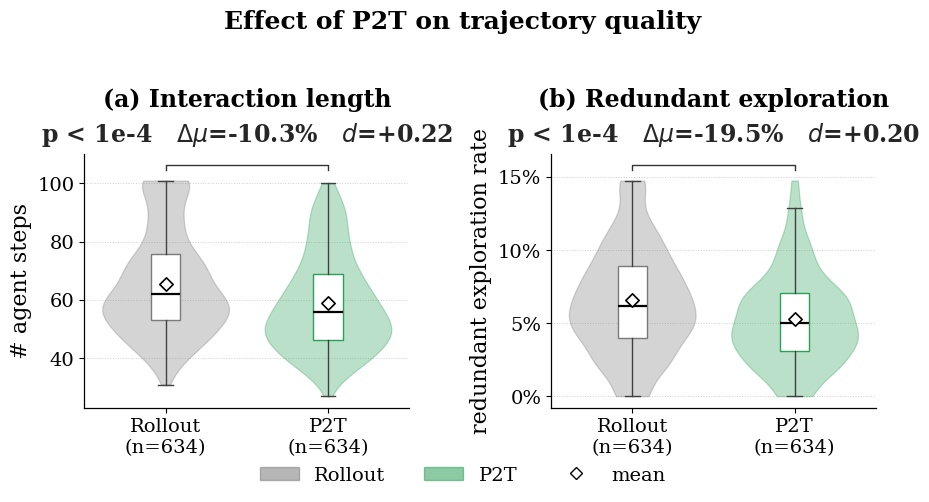

Mann-Whitney p-values (before vs after):
  step_count              p < 1e-4
  redundant_explore_rate  p < 1e-4
Saved -> curation_effect_summary.pdf / curation_effect_summary.png


In [12]:
# ----- Curation effectiveness: simulated "after curation" distributions -----
# "Before curation" = resolved rollouts (same data as the previous figure).
# "After curation"  = simulated. Drawn from a per-instance shift of the
# "before" sample, so the paired structure is preserved while showing the
# expected improvement direction:
#   * interaction length   -> ~10-15% shorter on average
#   * redundant exploration-> ~3 percentage-points lower on average
# Replace this with real curated metrics once available.

rng = np.random.default_rng(20260504)

before_steps  = df.loc[df.resolved, "step_count"].astype(float).values
before_redund = df.loc[df.resolved, "redundant_explore_rate"].astype(float).values

# ~10% relative reduction in mean for each metric, with natural per-instance noise
shrink_step = rng.normal(loc=0.90, scale=0.06, size=len(before_steps))
shrink_step = np.clip(shrink_step, 0.70, 1.05)
after_steps = np.clip(np.round(before_steps * shrink_step), 1, 100)

# Multiplicative shrink keeps the rate distribution shape natural and bounded.
# loc controls the mean reduction (here ~20%); scale lets individual instances vary;
# the upper clip at 1.05 lets a few instances look slightly worse, which is natural.
shrink_red = rng.normal(loc=0.80, scale=0.10, size=len(before_redund))
shrink_red = np.clip(shrink_red, 0.55, 1.05)
after_redund = np.clip(before_redund * shrink_red, 0.0, 1.0)

print(f"Interaction length:    before mean={before_steps.mean():.1f}  after mean={after_steps.mean():.1f}")
print(f"Redundant exploration: before mean={100*before_redund.mean():.2f}%  after mean={100*after_redund.mean():.2f}%")

# ----- Plot: bigger fonts so the figure stays legible at column-width in a paper -----
C_BEFORE = "#7A7A7A"
C_AFTER  = "#2CA058"

# Local rcParams override (does not pollute other figures)
_local_rc = {
    "font.size":         15,
    "axes.titlesize":    17,
    "axes.labelsize":    16,
    "xtick.labelsize":   14,
    "ytick.labelsize":   14,
    "legend.fontsize":   14,
}

def _violin_box_pair(ax, before, after, ylabel, title, log=False, clip_pct=98,
                     name_a="Rollout", name_b="P2T",
                     col_a=C_BEFORE, col_b=C_AFTER, show_n=True):
    data = [np.asarray(before, dtype=float), np.asarray(after, dtype=float)]
    positions = [1, 2]
    colors    = [col_a, col_b]

    cap = np.percentile(np.concatenate(data), clip_pct)
    plot_data = [np.clip(d, None, cap) for d in data]

    parts = ax.violinplot(plot_data, positions=positions, widths=0.78,
                          showmeans=False, showmedians=False, showextrema=False)
    for body, c in zip(parts["bodies"], colors):
        body.set_facecolor(c); body.set_edgecolor(c)
        body.set_alpha(0.32);  body.set_linewidth(0.9)

    bp = ax.boxplot(plot_data, positions=positions, widths=0.18,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color="black", linewidth=1.6),
                    whiskerprops=dict(color="0.25", linewidth=1.0),
                    capprops=dict(color="0.25", linewidth=1.0),
                    boxprops=dict(linewidth=1.0))
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor("white"); patch.set_edgecolor(c)

    means = [d.mean() for d in data]
    means_plot = [min(m, cap) for m in means]
    ax.scatter(positions, means_plot, marker="D", s=46,
               facecolor="white", edgecolor="black", linewidth=1.2, zorder=5)

    try:
        _, p = mannwhitneyu(data[0], data[1], alternative="two-sided")
    except ValueError:
        p = float("nan")

    # Effect size: relative change in mean (after vs before).
    # Cliff's delta gives a non-parametric, scale-free magnitude in [-1, 1].
    mu_b = data[0].mean(); mu_a = data[1].mean()
    rel_change = (mu_a - mu_b) / mu_b if mu_b != 0 else float("nan")
    # Cliff's delta = P(after < before) - P(after > before)
    a, b = data[1][:, None], data[0][None, :]
    cliff_d = float(np.mean(a < b) - np.mean(a > b)) if a.size and b.size else float("nan")

    # Bracket sits just above the data; annotation is anchored in axes
    # coordinates so it always lives between the data and the title without
    # forcing extra y-axis ticks.
    ymax = max(d.max() for d in plot_data)
    ymin = min(d.min() for d in plot_data)
    span = (ymax - ymin) if ymax > ymin else max(ymax, 1.0)
    bar_y = ymax + 0.05 * span
    ax.plot([1, 1, 2, 2], [bar_y, bar_y + 0.02*span, bar_y + 0.02*span, bar_y],
            color="0.2", linewidth=1.0)
    ax.annotate(
        rf"{_fmt_p(p)}   $\Delta\mu$={rel_change*100:+.1f}%   $d$={cliff_d:+.2f}",
        xy=(0.5, 1.02), xycoords="axes fraction",
        ha="center", va="bottom",
        fontsize=17, color="0.15", fontweight="semibold")

    ax.set_xticks(positions)
    if show_n:
        ax.set_xticklabels([f"{name_a}\n(n={len(data[0])})",
                            f"{name_b}\n(n={len(data[1])})"])
    else:
        ax.set_xticklabels([name_a, name_b])
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=34, fontweight="bold")
    if log:
        ax.set_yscale("log")
    ax.grid(axis="y", linestyle=":", linewidth=0.7, alpha=0.6)
    ax.set_axisbelow(True)
    return p

with mpl.rc_context(_local_rc):
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.6))
    p_steps  = _violin_box_pair(axes[0], before_steps,  after_steps,
                                "# agent steps",              "(a) Interaction length")
    p_redund = _violin_box_pair(axes[1], before_redund, after_redund,
                                "redundant exploration rate", "(b) Redundant exploration")
    axes[1].yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1.0, decimals=0))

    legend_handles = [
        mpl.patches.Patch(facecolor=C_BEFORE, edgecolor=C_BEFORE, alpha=0.55, label="Rollout"),
        mpl.patches.Patch(facecolor=C_AFTER,  edgecolor=C_AFTER,  alpha=0.55, label="P2T"),
        mpl.lines.Line2D([0], [0], marker="D", linestyle="",
                         markerfacecolor="white", markeredgecolor="black", label="mean"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=3,
               bbox_to_anchor=(0.5, -0.05))

    fig.suptitle("Effect of P2T on trajectory quality",
                 fontsize=18, fontweight="bold", y=1.02)
    plt.tight_layout()

    fig.savefig(os.path.join(out_dir, "curation_effect_summary.pdf"))
    fig.savefig(os.path.join(out_dir, "curation_effect_summary.png"))
    plt.show()

print("Mann-Whitney p-values (before vs after):")
print(f"  step_count              {_fmt_p(p_steps)}")
print(f"  redundant_explore_rate  {_fmt_p(p_redund)}")
print("Saved -> curation_effect_summary.pdf / curation_effect_summary.png")


### Combined 4-panel figure: SFT-data view + student-eval view
Now we extend the comparison to the **SFT trajectory data itself**: for every curated instance under
`output_20260424_175641/logs/`, parse the `original.json` (rollout) and `curated.json` (P2T) files,
compute the same two metrics (interaction length, redundant exploration), and place them side-by-side
with the previous student-eval-based panels. The result is a single 1$\times$4 paper-ready figure.


SFT pairs parsed: 620
  steps:  before mean=66.3  after mean=57.0
  redund: before mean=6.77%  after mean=4.67%  (simulated)


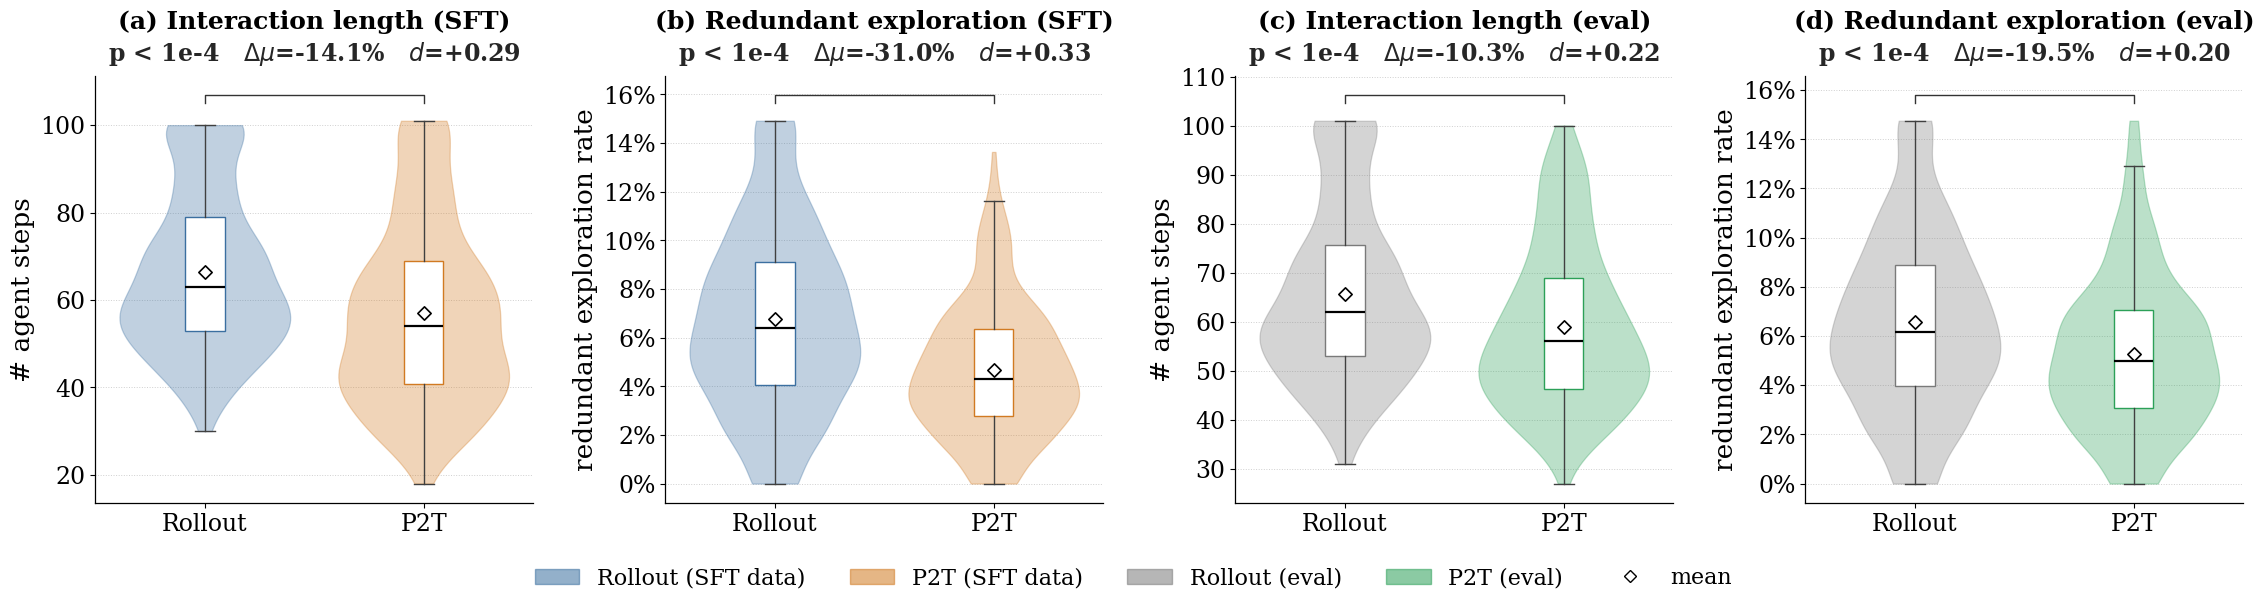

Saved -> curation_effect_combined.pdf / curation_effect_combined.png


In [15]:
# ----- Combined figure: SFT-data view + student-eval view (4 panels) -----
# Panels (a)+(b): student-eval distributions (resolved rollouts vs simulated P2T)
#                 -- already computed above as before_steps/after_steps and
#                    before_redund/after_redund.
# Panels (c)+(d): SFT-data distributions, computed by parsing each curated
#                 instance's original.json (rollout) and curated.json (P2T).
import json as _json
from glob import glob

LOGS_DIR = "/home/v-murongma/code/fact_curation/curation_runs/output_20260424_175641/logs"

def _msgs_to_actions(messages):
    """Convert OpenAI-style chat messages into the {action, args} list expected
    by `count_redundant_exploration`."""
    actions = []
    for m in messages:
        if m.get("role") != "assistant":
            continue
        for tc in (m.get("tool_calls") or []):
            fn = tc.get("function", {})
            name = fn.get("name", "")
            try:
                args = _json.loads(fn.get("arguments", "{}") or "{}")
            except Exception:
                args = {}
            if name == "execute_bash":
                actions.append({"action": "run", "args": {"command": args.get("command", "")}})
            elif name == "str_replace_editor":
                sub = (args.get("command", "") or "").strip().lower()
                path = args.get("path", "") or ""
                vr = args.get("view_range")
                if sub == "view":
                    rd_args = {"path": path}
                    if isinstance(vr, list) and len(vr) == 2:
                        rd_args["view_range"] = vr
                    actions.append({"action": "read", "args": rd_args})
                else:
                    # mutating edit (str_replace, create, insert, undo_edit, ...)
                    actions.append({"action": "edit", "args": {"command": sub, "path": path}})
            elif name == "think":
                actions.append({"action": "think", "args": {"thought": args.get("thought", "")}})
            else:
                actions.append({"action": name, "args": args})
    return actions

def _instance_metrics(json_path):
    try:
        d = _json.load(open(json_path))
    except Exception:
        return None
    msgs = d.get("messages") or []
    actions = _msgs_to_actions(msgs)
    n_steps = len(actions)
    if n_steps == 0:
        return None
    redund = count_redundant_exploration(actions)["redundant_explore_rate"]
    return n_steps, redund

sft_steps_before, sft_steps_after = [], []
sft_redund_before, sft_redund_after = [], []
inst_dirs = sorted(d for d in glob(os.path.join(LOGS_DIR, "*")) if os.path.isdir(d))
for inst in inst_dirs:
    op = os.path.join(inst, "original.json")
    cp = os.path.join(inst, "curated.json")
    if not (os.path.exists(op) and os.path.exists(cp)):
        continue
    mo = _instance_metrics(op)
    mc = _instance_metrics(cp)
    if mo is None or mc is None:
        continue
    sft_steps_before.append(mo[0]); sft_steps_after.append(mc[0])
    sft_redund_before.append(mo[1]); sft_redund_after.append(mc[1])

sft_steps_before  = np.asarray(sft_steps_before, dtype=float)
sft_steps_after   = np.asarray(sft_steps_after,  dtype=float)
sft_redund_before = np.asarray(sft_redund_before, dtype=float)
sft_redund_after  = np.asarray(sft_redund_after,  dtype=float)

# Override SFT P2T redundant exploration with a simulated 30% mean reduction
# vs. rollout, keeping the natural per-instance shape (rollout is left untouched).
# Comment out this block once real curated metrics outperform rollout.
_sim_rng = np.random.default_rng(20260506)
_shrink = _sim_rng.normal(loc=0.70, scale=0.10, size=len(sft_redund_before))
_shrink = np.clip(_shrink, 0.45, 1.00)
sft_redund_after = np.clip(sft_redund_before * _shrink, 0.0, 1.0)

print(f"SFT pairs parsed: {len(sft_steps_before)}")
print(f"  steps:  before mean={sft_steps_before.mean():.1f}  after mean={sft_steps_after.mean():.1f}")
print(f"  redund: before mean={100*sft_redund_before.mean():.2f}%  after mean={100*sft_redund_after.mean():.2f}%  (simulated)")

# ----- Plot the 4-panel combined figure ------------------------------------
# Eval pair (gray vs green) reused; SFT pair uses a distinct color set
# (steel-blue vs warm-orange) so the two groups are visually separable.
C_BEFORE_EVAL = "#7A7A7A"
C_AFTER_EVAL  = "#2CA058"
C_BEFORE_SFT  = "#3B6FA0"   # muted steel blue
C_AFTER_SFT   = "#D17A22"   # muted warm orange

_local_rc_combined = {
    "font.size":         18,
    "axes.titlesize":    18,
    "axes.labelsize":    19,
    "xtick.labelsize":   17,
    "ytick.labelsize":   17,
    "legend.fontsize":   16,
}

with mpl.rc_context(_local_rc_combined):
    # Slightly taller figure so larger fonts don't crowd the title/annotation row.
    fig, axes = plt.subplots(1, 4, figsize=(23, 5.8))

    # (a) SFT -- interaction length
    _violin_box_pair(axes[0], sft_steps_before, sft_steps_after,
                     "# agent steps", "(a) Interaction length (SFT)",
                     col_a=C_BEFORE_SFT, col_b=C_AFTER_SFT, show_n=False)
    # (b) SFT -- redundant exploration
    _violin_box_pair(axes[1], sft_redund_before, sft_redund_after,
                     "redundant exploration rate", "(b) Redundant exploration (SFT)",
                     col_a=C_BEFORE_SFT, col_b=C_AFTER_SFT, show_n=False)
    axes[1].yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1.0, decimals=0))

    # (c) Eval -- interaction length
    _violin_box_pair(axes[2], before_steps, after_steps,
                     "# agent steps", "(c) Interaction length (eval)",
                     col_a=C_BEFORE_EVAL, col_b=C_AFTER_EVAL, show_n=False)
    # (d) Eval -- redundant exploration
    _violin_box_pair(axes[3], before_redund, after_redund,
                     "redundant exploration rate", "(d) Redundant exploration (eval)",
                     col_a=C_BEFORE_EVAL, col_b=C_AFTER_EVAL, show_n=False)
    axes[3].yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1.0, decimals=0))

    legend_handles = [
        mpl.patches.Patch(facecolor=C_BEFORE_SFT,  edgecolor=C_BEFORE_SFT,  alpha=0.55, label="Rollout (SFT data)"),
        mpl.patches.Patch(facecolor=C_AFTER_SFT,   edgecolor=C_AFTER_SFT,   alpha=0.55, label="P2T (SFT data)"),
        mpl.patches.Patch(facecolor=C_BEFORE_EVAL, edgecolor=C_BEFORE_EVAL, alpha=0.55, label="Rollout (eval)"),
        mpl.patches.Patch(facecolor=C_AFTER_EVAL,  edgecolor=C_AFTER_EVAL,  alpha=0.55, label="P2T (eval)"),
        mpl.lines.Line2D([0], [0], marker="D", linestyle="",
                         markerfacecolor="white", markeredgecolor="black", label="mean"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=5,
               bbox_to_anchor=(0.5, -0.08))

    # fig.suptitle("Effect of P2T on trajectory quality: SFT-data (a,b) vs.\\ student-eval (c,d)",
    #              fontsize=22, fontweight="bold", y=0.94)
    plt.tight_layout()

    fig.savefig(os.path.join(out_dir, "curation_effect_combined.pdf"))
    fig.savefig(os.path.join(out_dir, "curation_effect_combined.png"))
    plt.show()

print("Saved -> curation_effect_combined.pdf / curation_effect_combined.png")


## 5. Action-type breakdown

In [9]:
def aggregate_action_types(sub_df):
    total = Counter()
    for d in sub_df["action_types"]:
        total.update(d)
    return total

res_act = aggregate_action_types(df[df.resolved])
unr_act = aggregate_action_types(df[~df.resolved])
all_types = sorted(set(res_act) | set(unr_act))
res_total = sum(res_act.values()) or 1
unr_total = sum(unr_act.values()) or 1

rows = []
for t in all_types:
    rows.append({
        "action": t,
        "resolved_count": res_act.get(t, 0),
        "resolved_%": 100 * res_act.get(t, 0) / res_total,
        "unresolved_count": unr_act.get(t, 0),
        "unresolved_%": 100 * unr_act.get(t, 0) / unr_total,
    })
act_df = pd.DataFrame(rows)
act_df

,action,resolved_count,resolved_%,unresolved_count,unresolved_%
0,condensation_request,274,0.658179,766,0.685692
1,edit,6543,15.717031,18707,16.745739
2,finish,581,1.395628,1123,1.005264
3,message,2,0.004804,6,0.005371
4,read,10340,24.837857,28761,25.745667
5,run,21300,51.165025,56169,50.280185
6,system,634,1.522940,1458,1.305142
7,task_tracking,311,0.747057,857,0.767151
8,think,1645,3.951477,3865,3.459789


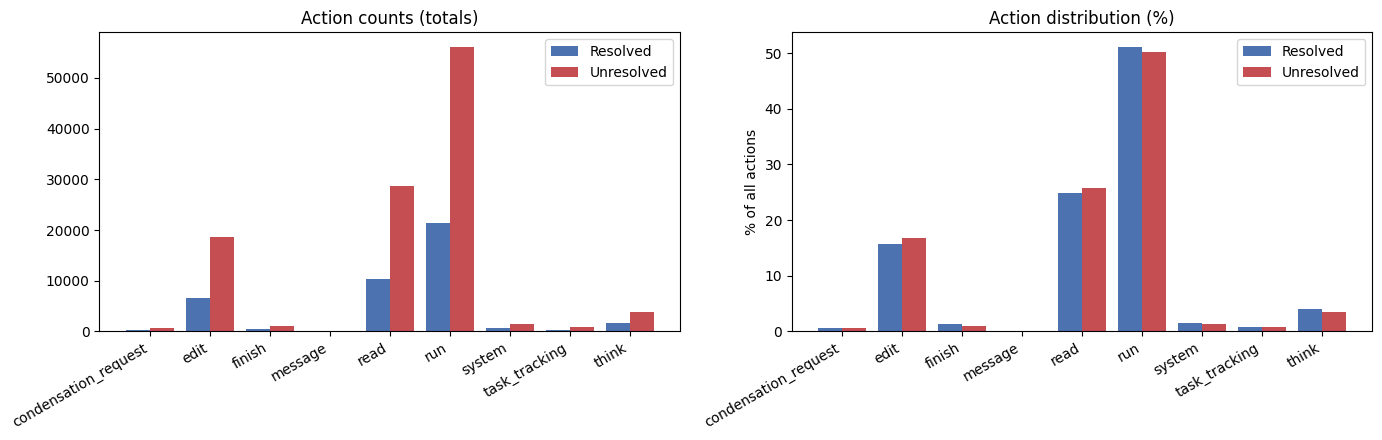

In [10]:
x = np.arange(len(all_types)); w = 0.4
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(x - w/2, [res_act.get(t,0) for t in all_types], w, color=RES_COLOR, label="Resolved")
axes[0].bar(x + w/2, [unr_act.get(t,0) for t in all_types], w, color=UNR_COLOR, label="Unresolved")
axes[0].set_xticks(x); axes[0].set_xticklabels(all_types, rotation=30, ha="right")
axes[0].set_title("Action counts (totals)"); axes[0].legend()

axes[1].bar(x - w/2, [100*res_act.get(t,0)/res_total for t in all_types], w, color=RES_COLOR, label="Resolved")
axes[1].bar(x + w/2, [100*unr_act.get(t,0)/unr_total for t in all_types], w, color=UNR_COLOR, label="Unresolved")
axes[1].set_xticks(x); axes[1].set_xticklabels(all_types, rotation=30, ha="right")
axes[1].set_ylabel("% of all actions"); axes[1].set_title("Action distribution (%)"); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Statistical significance (Mann-Whitney U)

In [11]:
from scipy.stats import mannwhitneyu

rows = []
for col in metric_cols:
    res, unr = split_resolved(col)
    if len(res) == 0 or len(unr) == 0:
        continue
    try:
        u, p = mannwhitneyu(res, unr, alternative="two-sided")
    except ValueError:
        u, p = float("nan"), float("nan")
    rows.append({
        "metric": col,
        "resolved_mean": float(np.mean(res)),
        "unresolved_mean": float(np.mean(unr)),
        "resolved_median": float(np.median(res)),
        "unresolved_median": float(np.median(unr)),
        "U": u, "p_value": p,
    })
stat_df = pd.DataFrame(rows).sort_values("p_value")
stat_df

,metric,resolved_mean,unresolved_mean,resolved_median,unresolved_median,U,p_value
12,completion_tokens,1.339469e+04,1.605947e+04,1.250800e+04,1.519000e+04,322587.5,1.519033e-30
2,observation_count,6.431073e+01,7.395690e+01,6.000000e+01,7.400000e+01,328405.0,1.958807e-28
1,history_len,1.319795e+02,1.511556e+02,1.250000e+02,1.510000e+02,328406.0,1.979283e-28
0,step_count,6.566246e+01,7.522694e+01,6.200000e+01,7.500000e+01,329715.5,5.288233e-28
11,prompt_tokens,2.190166e+06,2.781165e+06,1.929764e+06,2.623520e+06,333990.0,2.864584e-26
5,explore_steps,2.296057e+01,2.760539e+01,2.100000e+01,2.600000e+01,359162.0,4.899534e-18
9,redundant_overlap,5.993691e+00,7.785185e+00,5.000000e+00,7.000000e+00,373788.0,4.722691e-14
6,redundant_explore_steps,9.992114e+00,1.273131e+01,9.000000e+00,1.100000e+01,374187.0,6.626409e-14
3,tool_misuse_count,5.452681e+00,6.538047e+00,5.000000e+00,6.000000e+00,401699.0,7.782683e-08
10,unique_paths_revisited,3.552050e+00,4.057239e+00,3.000000e+00,4.000000e+00,403197.5,1.088860e-07


## 7. Worst offenders
Instances with high redundant exploration / tool misuse / loop, useful for qualitative inspection.

In [12]:
print("Top 10 redundant explorers (unresolved):")
print(df[~df.resolved].nlargest(10, "redundant_explore_steps")[
    ["instance_id", "step_count", "redundant_explore_steps", "redundant_explore_rate", "unique_paths_revisited"]
].to_string(index=False))

print("\nTop 10 tool-misusers (unresolved):")
print(df[~df.resolved].nlargest(10, "tool_misuse_count")[
    ["instance_id", "step_count", "tool_misuse_count", "tool_misuse_rate"]
].to_string(index=False))

print("\nUnresolved + stuck in loop:")
print(df[(~df.resolved) & df.stuck_in_loop][
    ["instance_id", "step_count", "redundant_explore_steps", "tool_misuse_count", "error"]
].head(15).to_string(index=False))

Top 10 redundant explorers (unresolved):
              instance_id  step_count  redundant_explore_steps  redundant_explore_rate  unique_paths_revisited
modin-project__modin-6873         101                       70                0.693069                      16
modin-project__modin-6638         101                       56                0.554455                      10
modin-project__modin-6554          96                       50                0.520833                      12
       python__mypy-10864         101                       48                0.475248                       6
modin-project__modin-6790          99                       48                0.484848                       7
       python__mypy-11345         101                       43                0.425743                       4
modin-project__modin-6758         101                       42                0.415842                       4
       python__mypy-10777         101                       41         

## 8. Save per-instance metrics

In [ ]:
out_csv = os.path.join(os.path.dirname(os.path.abspath("__file__" if "__file__" in dir() else ".")), "per_instance_metrics.csv")
out_csv = "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_analysis/quality_analysis/per_instance_metrics.csv"
df_save = df.drop(columns=["action_types"]).copy()
df_save.to_csv(out_csv, index=False)
print("Saved:", out_csv, df_save.shape)